In [1]:
import sqlite3
import pandas as pd

In [2]:
conn = sqlite3.connect('sales_project.db')
cursor = conn.cursor()


In [3]:
cursor.execute('''
CREATE TABLE IF NOT EXISTS customers (
    customer_id INTEGER PRIMARY KEY,
    name TEXT,
    city TEXT
)''')

In [4]:
cursor.execute('''
CREATE TABLE IF NOT EXISTS products (
    product_id INTEGER PRIMARY KEY,
    product_name TEXT,
    price INTEGER
)''')

In [5]:
cursor.execute('''
CREATE TABLE IF NOT EXISTS orders (
    order_id INTEGER PRIMARY KEY,
    customer_id INTEGER,
    product_id INTEGER,
    quantity INTEGER,
    order_date TEXT
)
''')

In [6]:
conn.commit()
print("✅ Tables ready!")

✅ Tables ready!


In [7]:
cursor.executemany("INSERT OR IGNORE INTO customers VALUES (?,?,?)", [
    (1, 'Amit',  'Mumbai'),
    (2, 'Priya', 'Delhi'),
    (3, 'Ravi',  'Pune'),
    (4, 'Sneha', 'Mumbai')
])

In [8]:
cursor.executemany("INSERT OR IGNORE INTO products VALUES (?,?,?)", [
    (1, 'Laptop',  50000),
    (2, 'Phone',   20000),
    (3, 'Tablet',  15000),
    (4, 'Earbuds',  3000)
])


In [9]:
cursor.executemany("INSERT OR IGNORE INTO orders VALUES (?,?,?,?,?)", [
    (1, 1, 1, 1, '2024-01-10'),
    (2, 2, 2, 2, '2024-01-15'),
    (3, 1, 4, 3, '2024-02-01'),
    (4, 3, 3, 1, '2024-02-20'),
    (5, 4, 2, 1, '2024-03-05'),
    (6, 2, 1, 1, '2024-03-18')
])

In [10]:
conn.commit()
print(" Data inserted!")

 Data inserted!


In [11]:

query = """
SELECT
    strftime('%m', order_date) AS month,
    SUM(p.price * o.quantity) AS monthly_sales
FROM orders o
JOIN products p ON o.product_id = p.product_id
GROUP BY month
ORDER BY month
"""
df = pd.read_sql_query(query, conn)
print(df)

  month  monthly_sales
0    01          90000
1    02          24000
2    03          70000


In [12]:
from sklearn.linear_model import LinearRegression
import numpy as np

In [13]:
df['month'] = df['month'].astype(int)


In [14]:
X = df[['month']]
y = df['monthly_sales']


In [15]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [16]:
next_month = np.array([[4]])
prediction = model.predict(next_month)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [17]:

print(f"April of predicted sales: ₹{prediction[0]:,.0f}")

April of predicted sales: ₹41,333


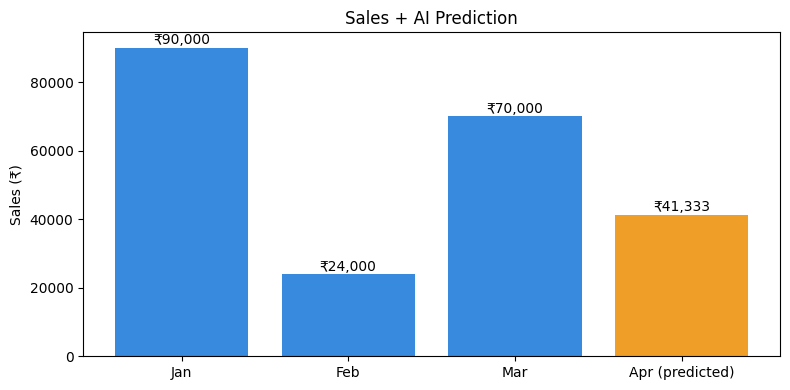

In [18]:
import matplotlib.pyplot as plt

months = ['Jan', 'Feb', 'Mar', 'Apr (predicted)']
sales  = list(df['monthly_sales']) + [int(prediction[0])]
colors = ['#378ADD', '#378ADD', '#378ADD', '#EF9F27']

plt.figure(figsize=(8, 4))
plt.bar(months, sales, color=colors)
plt.title('Sales + AI Prediction')
plt.ylabel('Sales (₹)')
for i, v in enumerate(sales):
    plt.text(i, v + 1000, f'₹{v:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()